# 📊 Vietnamese Sentiment Analysis (VSA): Food Reviews

**Project Objective:** Build a Machine Learning pipeline to classify Vietnamese restaurant reviews into two sentiments:
*   **Positive (1):** Satisfied customer experience.
*   **Negative (0):** Dissatisfied customer experience.

**Key Highlight:** The core classification algorithms (Multinomial Naive Bayes and Support Vector Machine) are **implemented entirely from scratch** to demonstrate a deep mathematical understanding of the underlying mechanics.


In [1]:
# 1. Install required packages (Uncomment if running on a new environment)
!pip install -q pyvi kagglehub

# 2. Standard Libraries
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import joblib

# 3. NLP & ML Tools
import kagglehub
from pyvi.ViTokenizer import ViTokenizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configure styling & warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_colwidth', 200)

import random
import os

def set_seed(seed: int = 42):
    """Ensure reproducibility across all runs."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(100)

## 1. Data Loading & Exploratory Data Analysis (EDA)
In this section, we fetch the dataset, handle missing or duplicated values, and explore the distribution of sentiments and comment lengths.

Note: The dataset exhibits class imbalance (~3:1 ratio for Positive:Negative). However, since we are strictly evaluating Custom ML implementations from scratch, we proceed without oversampling techniques like SMOTE, and will rely on Weighted F1-Score as our primary evaluation metric rather than raw Accuracy.

Using Colab cache for faster access to the 'vietnamese-sentiment-analysis-food-reviews' dataset.
Data shape before cleaning: (22847, 2) | After cleaning: (12922, 2)


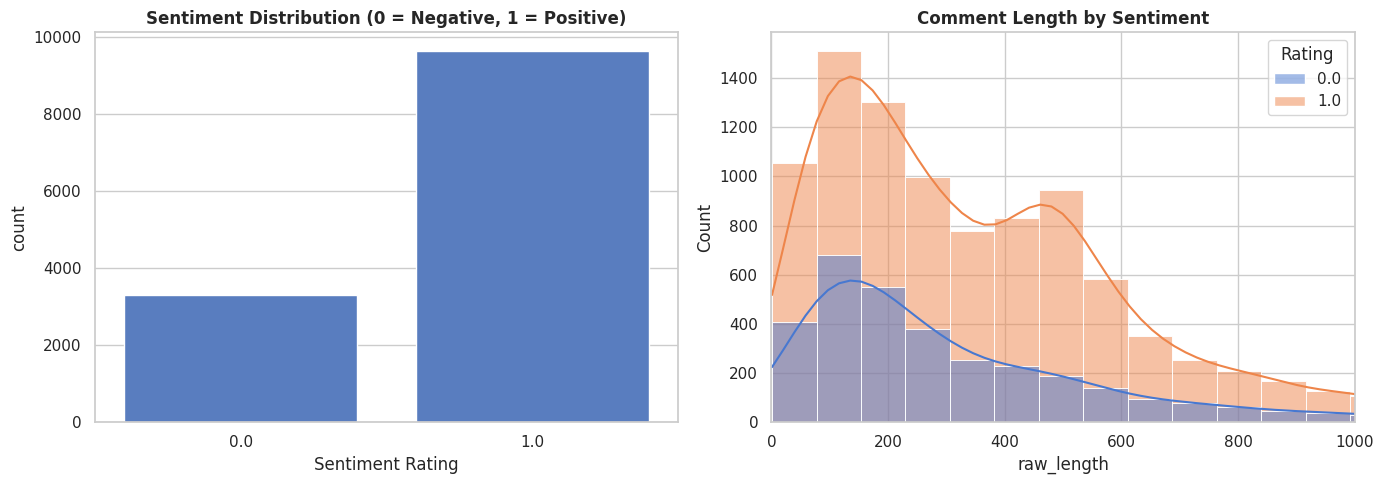

In [2]:
# Load dataset
path = kagglehub.dataset_download("guutran/vietnamese-sentiment-analysis-food-reviews")
data = pd.read_csv(f"{path}/vsa_food_rv_train.csv")

# Data Cleaning: Drop duplicates and missing values
initial_shape = data.shape
data.drop_duplicates(subset=['Comment'], keep="first", inplace=True)
data.dropna(inplace=True)
print(f"Data shape before cleaning: {initial_shape} | After cleaning: {data.shape}")

# Visualize Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sentiment Distribution
sns.countplot(x='Rating', data=data, ax=axes[0])
axes[0].set_title("Sentiment Distribution (0 = Negative, 1 = Positive)", fontweight='bold')
axes[0].set_xlabel("Sentiment Rating")

# Plot 2: Comment Length Distribution
data['raw_length'] = data['Comment'].apply(lambda x: len(str(x)))
sns.histplot(data=data, x='raw_length', hue='Rating', bins=50, kde=True, ax=axes[1])
axes[1].set_title("Comment Length by Sentiment", fontweight='bold')
axes[1].set_xlim(0, 1000) # Cap at 1000 for better visualization

plt.tight_layout()
plt.show()

## 2. Text Preprocessing & Feature Engineering
Vietnamese NLP requires robust preprocessing. We handle internet slang (teencode), remove noise (HTML, URLs, punctuations), and tokenize compound words using `pyvi`.

In [3]:
# Dictionary for normalizing common Vietnamese internet slang
TEENCODE_DICT = {
    'k': 'không', 'ko': 'không', 'khong': 'không', 'kg': 'không',
    'đéo': 'không', 'éo': 'không', 'đếch': 'không', 'dell': 'không', 'chả': 'không',
    'dc': 'được', 'đc': 'được', 'ok': 'tốt', 'oke': 'tốt', 'okie': 'tốt',
    'vs': 'với', 'r': 'rồi', 'rùi': 'rồi',
    'quá': 'rất', 'qá': 'rất', 'vcl': 'rất', 'vl': 'rất', 'vãi': 'rất'
}

# Text Preprocessing Function
def clean_and_tokenize(text):
    #Normalizes, cleans Vietnamese text and removes teencode.
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+|<.*?>', ' ', text)

    # Normalize internet slang/teencode
    words = text.split()
    words = [TEENCODE_DICT.get(w, w) for w in words]
    text = ' '.join(words)

    # Remove punctuations and retain valid Vietnamese characters
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    text = text.translate(translator)
    text = re.sub(r'[^a-z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text # Return clean string (before PyVi tokenization)

print("Preprocessing text data...")
# 1. Calculate length on the clean string (matching original logic)
data['cleaned_comment'] = data['Comment'].apply(clean_and_tokenize)
data['comment_length'] = data['cleaned_comment'].apply(len)

# 2. Apply ViTokenizer after length calculation
data['processed_comment'] = data['cleaned_comment'].apply(ViTokenizer.tokenize)

# 3. Length Feature Scaling
scaler = StandardScaler()
data['comment_length_scaled'] = scaler.fit_transform(data[['comment_length']])
joblib.dump(scaler, 'length_scaler.pkl')

# 4. Train-Test Split (Removed stratify=y to match the exact original split)
X = data[['processed_comment', 'comment_length_scaled']]
y = data['Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 3))
X_train_tfidf = tfidf.fit_transform(X_train['processed_comment'])
X_test_tfidf = tfidf.transform(X_test['processed_comment'])
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# 6. Combine Features (TF-IDF + Scaled Length)
X_train_combined = scipy.sparse.hstack([X_train_tfidf, X_train[['comment_length_scaled']].values]).tocsr()
X_test_combined = scipy.sparse.hstack([X_test_tfidf, X_test[['comment_length_scaled']].values]).tocsr()

print(f"Final Feature Matrix Shape (Train): {X_train_combined.shape}")

Preprocessing text data...
Final Feature Matrix Shape (Train): (10337, 5001)


## 3. Custom Machine Learning Models (From Scratch)
Implementing standard algorithms without utilizing `scikit-learn`'s modeling API to demonstrate underlying algorithmic mathematics.
*   **Naive Bayes:** Incorporates Laplace smoothing ($\alpha = 1.0$).
*   **SVM:** Implements a simplified Sequential Minimal Optimization (SMO) algorithm for the Dual SVM problem.

In [4]:
# ======================== NAIVE BAYES FROM SCRATCH ========================
class NaiveBayesClassifier:
    """Multinomial Naive Bayes classifier implemented from scratch."""

    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_priors = {}
        self.feature_probs = {}
        self.classes = None
        self.n_features = None

    def fit(self, X, y):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X)
        y = np.array(y)

        self.classes = np.unique(y)
        self.n_features = X.shape[1]

        for cls in self.classes:
            X_cls = X[y == cls]
            self.class_priors[cls] = len(X_cls) / len(X)

            feature_counts = np.sum(X_cls, axis=0)
            denominator = np.sum(feature_counts) + self.alpha * self.n_features
            self.feature_probs[cls] = np.log((feature_counts + self.alpha) / denominator)

    def predict(self, X):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X)
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples)

        for i in range(n_samples):
            y_pred[i] = self._predict_single(X[i])
        return y_pred

    def _predict_single(self, x):
        posteriors = {}
        for cls in self.classes:
            prior = np.log(self.class_priors[cls])
            likelihood = np.sum(self.feature_probs[cls] * x)
            posteriors[cls] = prior + likelihood
        return max(posteriors, key=posteriors.get)

In [5]:
# ======================== SVM FROM SCRATCH ========================
class SVM:
    """Support Vector Machine using simplified SMO algorithm (binary classification)."""

    def __init__(self, C=1.0, kernel='linear', gamma=0.1, epsilon=1e-6, max_iter=1000):
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_iter = max_iter

        self.alphas = None
        self.b = 0
        self.support_vectors = None
        self.support_vector_labels = None
        self.X_train = None
        self.y_train = None
        self.classes = None

    def _kernel(self, x1, x2):
        if self.kernel == 'linear':
            return np.dot(x1, x2)
        elif self.kernel == 'rbf':
            return np.exp(-self.gamma * np.sum((x1 - x2) ** 2))
        elif self.kernel == 'poly':
            return (1 + np.dot(x1, x2)) ** 3

    def fit(self, X, y):
        if hasattr(X, 'toarray'):
            X = X.toarray()

        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64)

        self.X_train = X
        self.y_train = y
        self.classes = np.unique(y)

        if set(self.classes) == {0, 1}:
            y = np.where(y == 0, -1, 1)

        n_samples = X.shape[0]
        self.alphas = np.zeros(n_samples)
        self.b = 0

        passes = 0
        while passes < self.max_iter:
            changed = 0
            for i in range(n_samples):
                E_i = self._predict_single(X[i]) - y[i]

                if ((y[i] * E_i < -self.epsilon and self.alphas[i] < self.C) or
                    (y[i] * E_i > self.epsilon and self.alphas[i] > 0)):

                    j = np.random.randint(0, n_samples)
                    if i == j:
                        j = (j + 1) % n_samples

                    E_j = self._predict_single(X[j]) - y[j]
                    alpha_i_old = self.alphas[i]
                    alpha_j_old = self.alphas[j]

                    if y[i] != y[j]:
                        L = max(0, self.alphas[j] - self.alphas[i])
                        H = min(self.C, self.C + self.alphas[j] - self.alphas[i])
                    else:
                        L = max(0, self.alphas[i] + self.alphas[j] - self.C)
                        H = min(self.C, self.alphas[i] + self.alphas[j])

                    if L == H:
                        continue

                    eta = 2 * self._kernel(X[i], X[j]) - self._kernel(X[i], X[i]) - self._kernel(X[j], X[j])
                    if eta >= 0:
                        continue

                    self.alphas[j] = self.alphas[j] - y[j] * (E_i - E_j) / eta
                    self.alphas[j] = np.clip(self.alphas[j], L, H)

                    if abs(self.alphas[j] - alpha_j_old) < self.epsilon:
                        continue

                    self.alphas[i] = self.alphas[i] + y[i] * y[j] * (alpha_j_old - self.alphas[j])

                    b1 = self.b - E_i - y[i] * (self.alphas[i] - alpha_i_old) * self._kernel(X[i], X[i]) - y[j] * (self.alphas[j] - alpha_j_old) * self._kernel(X[i], X[j])
                    b2 = self.b - E_j - y[i] * (self.alphas[i] - alpha_i_old) * self._kernel(X[i], X[j]) - y[j] * (self.alphas[j] - alpha_j_old) * self._kernel(X[j], X[j])

                    if 0 < self.alphas[i] < self.C:
                        self.b = b1
                    elif 0 < self.alphas[j] < self.C:
                        self.b = b2
                    else:
                        self.b = (b1 + b2) / 2

                    changed += 1

            passes += 1
            if changed == 0:
                passes += 1
            else:
                passes = 0

        sv_indices = self.alphas > self.epsilon
        self.support_vectors = X[sv_indices]
        self.support_vector_labels = y[sv_indices]
        self.alphas = self.alphas[sv_indices]

    def _predict_single(self, x):
        if self.support_vectors is None:
            return self.b
        prediction = self.b
        for alpha, sv, sv_label in zip(self.alphas, self.support_vectors, self.support_vector_labels):
            prediction += alpha * sv_label * self._kernel(x, sv)
        return prediction

    def predict(self, X):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        X = np.array(X, dtype=np.float64)
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples)

        for i in range(n_samples):
            prediction = self._predict_single(X[i])
            y_pred[i] = self.classes[1] if prediction >= 0 else self.classes[0]
        return y_pred

## 4. Model Training & Evaluation
We will train both custom models on our TF-IDF + Length feature space and evaluate their performance visually using Confusion Matrices and standard classification metrics.

In [6]:
# Instantiate and train the Custom Naive Bayes model
nb_model = NaiveBayesClassifier(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# Perform predictions on the test set
y_pred_nb = nb_model.predict(X_test_tfidf).astype(int)

# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print("=" * 50)
print("NAIVE BAYES PERFORMANCE (FROM SCRATCH)")
print("=" * 50)
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall: {nb_recall:.4f}")
print(f"F1-Score: {nb_f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

NAIVE BAYES PERFORMANCE (FROM SCRATCH)
Accuracy: 0.9002
Precision: 0.9001
Recall: 0.9002
F1-Score: 0.8947

Confusion Matrix:
[[ 417  211]
 [  47 1910]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.66      0.76       628
         1.0       0.90      0.98      0.94      1957

    accuracy                           0.90      2585
   macro avg       0.90      0.82      0.85      2585
weighted avg       0.90      0.90      0.89      2585



In [7]:
# Instantiate and train the Custom SVM model
print("Đang huấn luyện SVM (có thể mất vài giây)...")
svm_model = SVM(C=1.0, kernel='linear', gamma=0.1, epsilon=1e-6, max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

# Perform predictions on the test set
y_pred_svm = svm_model.predict(X_test_tfidf).astype(int)

# Evaluate model performance
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print("=" * 50)
print("SUPPORT VECTOR MACHINE PERFORMANCE (FROM SCRATCH)")
print("=" * 50)
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1-Score: {svm_f1:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

Đang huấn luyện SVM (có thể mất vài giây)...
SUPPORT VECTOR MACHINE PERFORMANCE (FROM SCRATCH)
Accuracy: 0.8685
Precision: 0.8809
Recall: 0.8685
F1-Score: 0.8723

Confusion Matrix:
[[ 522  106]
 [ 234 1723]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.83      0.75       628
         1.0       0.94      0.88      0.91      1957

    accuracy                           0.87      2585
   macro avg       0.82      0.86      0.83      2585
weighted avg       0.88      0.87      0.87      2585



## 5. Inference Pipeline
A robust prediction function designed for production. It takes raw text, applies the exact preprocessing pipeline (Cleaning $\rightarrow$ Tokenization $\rightarrow$ TF-IDF $\rightarrow$ Scaling), and returns the sentiment.

In [8]:
# 5. Inference Pipeline
def predict_sentiment(text, model, tfidf_vec):
    """End-to-end inference function using only TF-IDF features (matching original model)."""
    # 1. Preprocess text using your original logic
    processed_text = clean_and_tokenize(text)
    processed_text = ViTokenizer.tokenize(processed_text)

    # 2. Extract TF-IDF features (5000 features)
    X_input = tfidf_vec.transform([processed_text])

    # 3. Predict
    prediction = model.predict(X_input)[0]
    sentiment = "Positive 😊" if prediction == 1 else "Negative 😞"

    print(f"Text: '{text}'")
    print(f"Prediction: {sentiment}\n" + "-"*50)

# Load saved preprocessor
saved_tfidf = joblib.load('tfidf_vectorizer.pkl')
best_model = svm_model # or svm_model depending on your preference

# Test Cases
test_comments = [
    "Quán phục vụ nhanh tuyệt vời, gọi món có 2 tiếng là mang ra", # Sarcastic/Negative
    "Chất lượng tệ, giá đắt, service chậm. Không bao giờ quay lại.", # Negative
    "Đồ ăn ngon, giá hợp lý nhưng chỗ để xe hơi chật.", # Neutral/Positive
    "Tuyệt vời! Đồ ăn tươi, nóng, ngon. Nhân viên thân thiện." # Positive
]

print("🚀 INFERENCE PIPELINE DEMO\n" + "="*50)
for comment in test_comments:
    predict_sentiment(comment, best_model, saved_tfidf)

🚀 INFERENCE PIPELINE DEMO
Text: 'Quán phục vụ nhanh tuyệt vời, gọi món có 2 tiếng là mang ra'
Prediction: Positive 😊
--------------------------------------------------
Text: 'Chất lượng tệ, giá đắt, service chậm. Không bao giờ quay lại.'
Prediction: Negative 😞
--------------------------------------------------
Text: 'Đồ ăn ngon, giá hợp lý nhưng chỗ để xe hơi chật.'
Prediction: Positive 😊
--------------------------------------------------
Text: 'Tuyệt vời! Đồ ăn tươi, nóng, ngon. Nhân viên thân thiện.'
Prediction: Positive 😊
--------------------------------------------------


NAIVE BAYES PERFORMANCE (FROM SCRATCH)
Accuracy:  0.9002
Precision: 0.9001
Recall:    0.9002
F1-Score:  0.8947

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.66      0.76       628
         1.0       0.90      0.98      0.94      1957

    accuracy                           0.90      2585
   macro avg       0.90      0.82      0.85      2585
weighted avg       0.90      0.90      0.89      2585



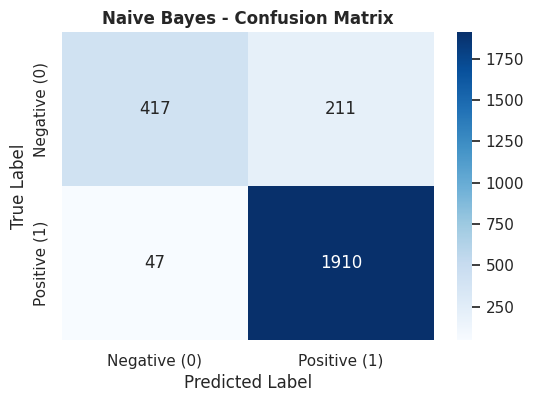

In [9]:
# 1. Print Metrics
print("=" * 50)
print("NAIVE BAYES PERFORMANCE (FROM SCRATCH)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_nb, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, zero_division=0))

# 2. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('Naive Bayes - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

SUPPORT VECTOR MACHINE PERFORMANCE (FROM SCRATCH)
Accuracy:  0.8685
Precision: 0.8809
Recall:    0.8685
F1-Score:  0.8723

Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.83      0.75       628
         1.0       0.94      0.88      0.91      1957

    accuracy                           0.87      2585
   macro avg       0.82      0.86      0.83      2585
weighted avg       0.88      0.87      0.87      2585



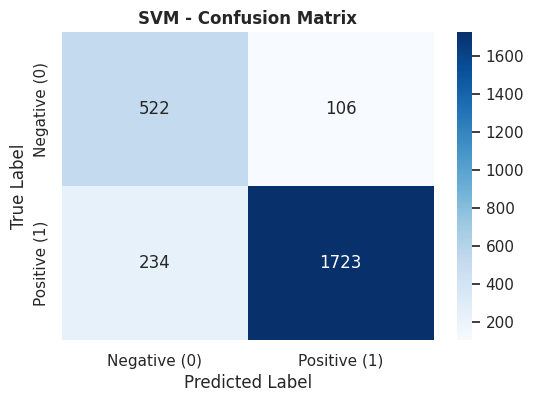

In [10]:
# 1. Print Metrics
print("=" * 50)
print("SUPPORT VECTOR MACHINE PERFORMANCE (FROM SCRATCH)")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, zero_division=0))

# 2. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title('SVM - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()